Check Python version

In [1]:
!python --version

Python 3.11.11


Import libraries

In [2]:
import json
import yaml
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

### **Extract Data**

In [3]:
# Local directory
data_dir = '../datasets/air_quality'
file_name = 'air_quality'
file_path = f'{data_dir}/{file_name}.csv'

In [4]:
dataset = pd.read_csv(file_path)

In [5]:
dataset.shape

(9471, 14)

In [6]:
dataset.columns

Index(['datetime', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'RH', 'AH', 'T'],
      dtype='object')

In [7]:
dataset.head()

,datetime,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,T
0,10-03-2004 18:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,48.9,0.7578,13.6
1,10-03-2004 19:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,47.7,0.7255,13.3
2,10-03-2004 20:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,54.0,0.7502,11.9
3,10-03-2004 21:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,60.0,0.7867,11.0
4,10-03-2004 22:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,59.6,0.7888,11.2


In [8]:
dataset.tail()

,datetime,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,T
9466,04-04-2005 14:00,2.2,1071,275,11.9,1047,265,654,168,1129,816,13.1,0.5028,28.5
9467,04-04-2005 14:00,2.2,1071,275,11.9,1047,265,654,168,1129,816,13.1,0.5028,28.5
9468,04-04-2005 14:00,2.2,1071,275,11.9,1047,265,654,168,1129,816,13.1,0.5028,28.5
9469,04-04-2005 14:00,2.2,1071,275,11.9,1047,265,654,168,1129,816,13.1,0.5028,28.5
9470,04-04-2005 14:00,2.2,1071,275,11.9,1047,265,654,168,1129,816,13.1,0.5028,28.5


Define the required time and target columns

In [9]:
time_col = dataset.columns[0]
dataset[time_col] = pd.to_datetime(dataset[time_col], format="%d-%m-%Y %H:%M", errors='coerce')
time_col = dataset.columns[0]
target_col = dataset.columns[-1]
dataset[time_col] = dataset[time_col].astype(str)

Change target column to float

In [10]:
# dataset[target_col] = dataset[target_col].astype(float)

In [11]:
# dataset.head()

Split dataset into train and test sets

In [12]:
train_size = 0.9
train_points = int(train_size*len(dataset))
train_df = dataset.iloc[:train_points]
test_df = dataset.iloc[train_points:]

Plot graph

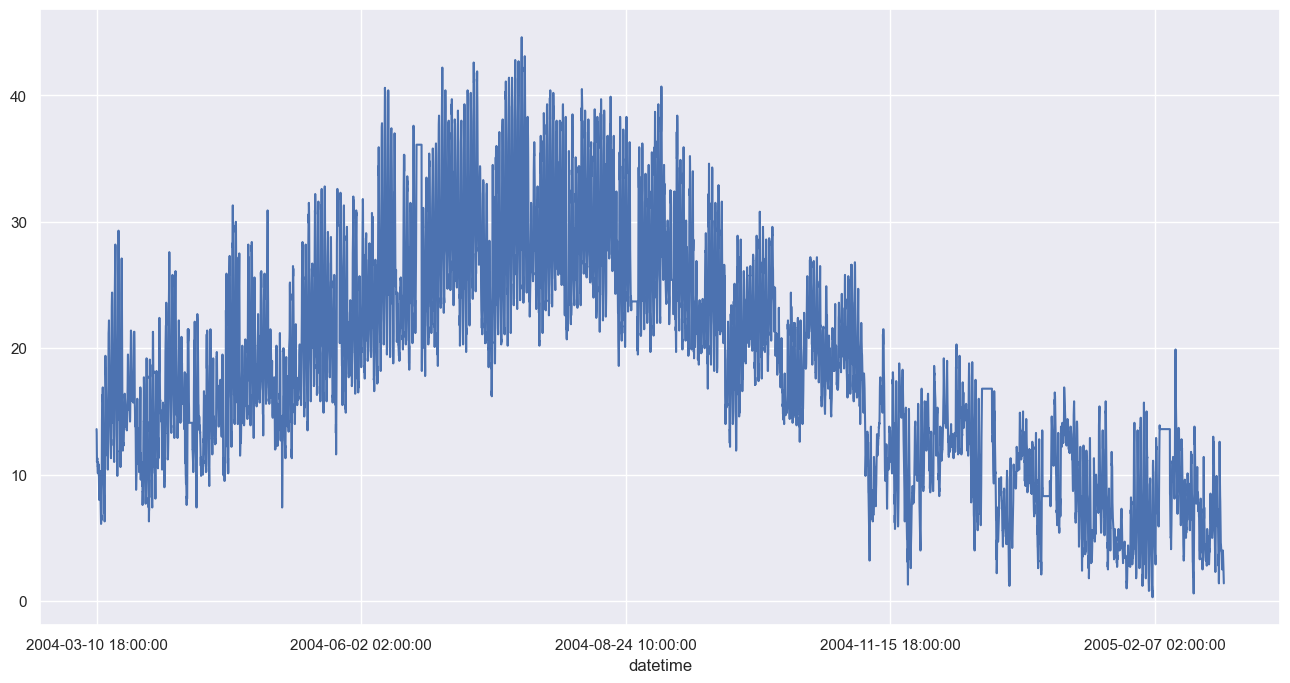

In [13]:
figsize = (16, 8)
train_df.set_index(time_col)[target_col].plot(figsize=figsize);

### **Train API**

Train data: convert df to list-of-list

In [14]:
train_data = []
for value in train_df.values:
    train_data.append(list(value))

In [15]:
train_data[:2]

[['2004-03-10 18:00:00',
  2.6,
  1360,
  150,
  11.9,
  1046,
  166,
  1056,
  113,
  1692,
  1268,
  48.9,
  0.7578,
  13.6],
 ['2004-03-10 19:00:00',
  2.0,
  1292,
  112,
  9.4,
  955,
  103,
  1174,
  92,
  1559,
  972,
  47.7,
  0.7255,
  13.3]]

Custom Model Request (optional)

In [16]:
# Default model request
# model_request = {
#     'type': 'meta_wa',
#     'scorers': ['smape', 'mase'],
#     'params': {
#         'preprocessors': [
#             {'type': 'dartsimputer'},
#             {'type': 'minmaxscaler'},
#         ],
#         'base_models': [
#             # {'type': 'darts_naive'},
#             {'type': 'darts_seasonalnaive'},
#             # {'type': 'darts_autotheta'},
#             # {'type': 'darts_autoarima'},
#             # {'type': 'darts_autoets'},
#         ],
#     },
# }

# # Onboard NeuralProphet customized model request
# np_external_model_request = {
#     'params': {
#       'changepoints_range': 0.2,
#       'epochs': 2,
#       'growth': 'off'
#     },
#     'metrics': [],
#     'type': 'neuralprophet',
# }
# # np_external_model_request = None

user_value = 0.9
output_type = 'estimate'  # 'data', 'estimate'
mauq_external_params = {
    'problem_type': 'regression',
    'confidence_level': user_value,
    'output_type': output_type

}

deepsybil_external_model_request = {
    'type': 'meta_wa',  # 'meta_naive', 'meta_wa'
    'scorers': ['mase', 'smape'],
    'params': {
        'preprocessors': [
            # {'type': 'dartsimputer'},
            # {'type': 'simpleimputer', 'params': {'strategy': 'mean'}},
            {'type': 'minmaxscaler'},
        ],
        'base_models': [
            # {'type': 'darts_rnn',
            #  'params': {
            #      'model': 'LSTM',
            #      'hidden_dim': 10,
            #      'n_rnn_layers': 3
            # }},
            # {'type': 'darts_tcn',
            #  'params': {
            #      'output_chunk_length': 52,
            #      'input_chunk_length': 104,                 
            #      'n_epochs': 20,
            # }},
            # {'type': 'darts_rnn',
            #  'params': {
            #      'model': 'LSTM',
            #      'hidden_dim': 10,
            #      'n_rnn_layers': 3
            # }},
            # {'type': 'darts_nlinear'},
            # {'type': 'darts_dlinear'},
            # {'type': 'darts_blockrnn'},
            # {'type': 'darts_tsmixer',
            #  'params': {
            #      'output_chunk_length': 52,
            #      'input_chunk_length': 104,                 
            #      'n_epochs': 20,
            # }},
             {'type': 'darts_tsmixer'}
        ],
    },
}


# # Customized model request
model_request = {
    'type': 'meta_wa',  # 'meta_naive', 'meta_wa'
    'scorers': ['mase', 'smape'],
    'params': {
        'preprocessors': [
            # {'type': 'dartsimputer'},
            # {'type': 'simpleimputer', 'params': {'strategy': 'mean'}},
            # {'type': 'minmaxscaler'},
        ],
        'base_models': [
            # {'type': 'darts_naive'},
            # {'type': 'darts_seasonalnaive'},
            # {'type': 'darts_autotheta'},
            # {'type': 'stats_autotheta'},
            # {'type': 'darts_autoets'},
            # {'type': 'stats_autoets'},
            # {'type': 'darts_autoarima'},
            # {'type': 'stats_autoarima'},
            # {'type': 'darts_autoces'},
            # {'type': 'darts_kalman'},
            # {'type': 'darts_catboost'},            
            # # {'type': 'darts_tbats'},
            # # {'type': 'darts_linearregression'},
            # {'type': 'darts_lightgbm',
            #  'params': {
            #      'lags': 12,
            #      'output_chunk_length': 6,
            #      'verbose': -1
            # }}
            # {'type': 'neuralprophet',
            #  'external_params': np_external_model_request
            # }  # Onboard NeuralProphet external service
            {'type': 'deepsybil',
             'external_params': deepsybil_external_model_request
            }  # Onboard NeuralProphet external service
        ],
        
    },
    'mauq_params':mauq_external_params,
}

This is for JSON model_request

In [17]:
# file_path = 'model_request.json'
# # For writing the model request to a json file
# with open(file_path, 'r') as file:
#     model_request = json.load(file)

This is for YAML model_request

In [18]:
# file_path = 'model_request.yaml'
# # For reading the model request from a yaml file
# with open(file_path, 'r') as file:
#     model_request = yaml.safe_load(file)

Train API JSON Payload

In [19]:
api_json = {
    'data': train_data,
    'model': model_request  # (optional) can be commented out
}

Build URL

In [20]:
with open('url.yaml', 'r') as file:
    url_dict = yaml.safe_load(file)

In [21]:
# URL to our SYBIL AWS service
protocol = url_dict['protocol']
host = url_dict['host']
port = url_dict['port']
endpoint = 'train'

url = '%s://%s:%s/%s' % (protocol, host, str(port), endpoint)

In [22]:
# protocol, host, port

Call endpoint, receive response JSON, write to output file

In [23]:
%%time
response = requests.post(url, json=api_json)
print(response)
print()

<Response [500]>

CPU times: total: 15.6 ms
Wall time: 10min 2s


In [24]:
train_json_out = response.json()  # dict output
train_json_out

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
estimate=train_json_out['estimate']

### **Forecast API**

Forecast Dates: predict the next 32 years of temperature anomaly data (1980-2012)

In [ ]:
test_data = []
for value in test_df.drop(columns=target_col).values:
    test_data.append(list(value))

In [ ]:
test_data[:2]

[['1996',
  2.88519,
  0.449892,
  -0.0223544,
  -0.205278,
  0.0539366,
  0.00211465,
  -0.178961,
  -0.696683,
  -0.0647351],
 ['1997',
  2.92642,
  0.451832,
  -0.0026152,
  -0.205278,
  0.0539366,
  0.00212411,
  -0.181594,
  -0.696581,
  -0.0324204]]

Model from Train API

In [ ]:
model = train_json_out['model']

Forecast API JSON Payload

In [ ]:
api_json = {
    'model': model,
    'data': test_data,
    'estimate':estimate
}

Build URL (same as train except for the endpoint)

In [ ]:
endpoint = 'forecast'

url = '%s://%s:%s/%s' % (protocol, host, str(port), endpoint)

Call endpoint, receive response JSON, write to output file

In [ ]:
%%time
response = requests.post(url, json=api_json)
print(response)
print()

<Response [200]>

CPU times: total: 15.6 ms
Wall time: 4.38 s


In [ ]:
forecast_json_out = response.json()  # dict output
forecast_json_out

{'data': [['1996',
   0.35479950452758297,
   -0.05285842927114326,
   0.7624574383263092],
  ['1997', 0.3015131730084257, -0.10614476079030055, 0.7091711068071519],
  ['1998', 0.3499440302583476, -0.05771390354037864, 0.7576019640570738],
  ['1999', 0.3610268998887805, -0.04663103390994572, 0.7686848336875067],
  ['2000', 0.3340497156539522, -0.07360821814477403, 0.7417076494526784],
  ['2001', 0.2977334085496764, -0.10992452524904983, 0.7053913423484026],
  ['2002', 0.34291317067281485, -0.06474476312591138, 0.7505711044715411],
  ['2003', 0.3381756714458532, -0.06948226235287303, 0.7458336052445794],
  ['2004', 0.32377252878134194, -0.08388540501738428, 0.7314304625800682],
  ['2005', 0.29651765290120474, -0.11114028089752148, 0.704175586699931],
  ['2006', 0.33859265868257277, -0.06906527511615346, 0.746250592481299],
  ['2007', 0.3279862176784432, -0.07967171612028301, 0.7356441514771694],
  ['2008', 0.31889430091775056, -0.08876363288097566, 0.7265522347164768],
  ['2009', 0.3146

Combine forecast dates and output

In [ ]:
forecast_df = pd.DataFrame(
    data=forecast_json_out['data'],
    columns=[time_col, target_col,"lower_interval","upper_interval"],
)

In [ ]:
forecast_df.shape

(17, 4)

In [ ]:
forecast_df.columns

Index(['Year', 'Anomaly', 'lower_interval', 'upper_interval'], dtype='object')

In [ ]:
forecast_df.head()

,Year,Anomaly,lower_interval,upper_interval
0,1996,0.354800,-0.052858,0.762457
1,1997,0.301513,-0.106145,0.709171
2,1998,0.349944,-0.057714,0.757602
3,1999,0.361027,-0.046631,0.768685
4,2000,0.334050,-0.073608,0.741708


In [ ]:
forecast_df.tail()

,Year,Anomaly,lower_interval,upper_interval
12,2008,0.318894,-0.088764,0.726552
13,2009,0.314655,-0.093003,0.722313
14,2010,0.294820,-0.112838,0.702478
15,2011,0.337095,-0.070563,0.744753
16,2012,0.319245,-0.088413,0.726903


Plot train and forecast side-by-side

C:\Users\saira\AppData\Local\Temp\ipykernel_25160\2998340865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['color'] = 'b'


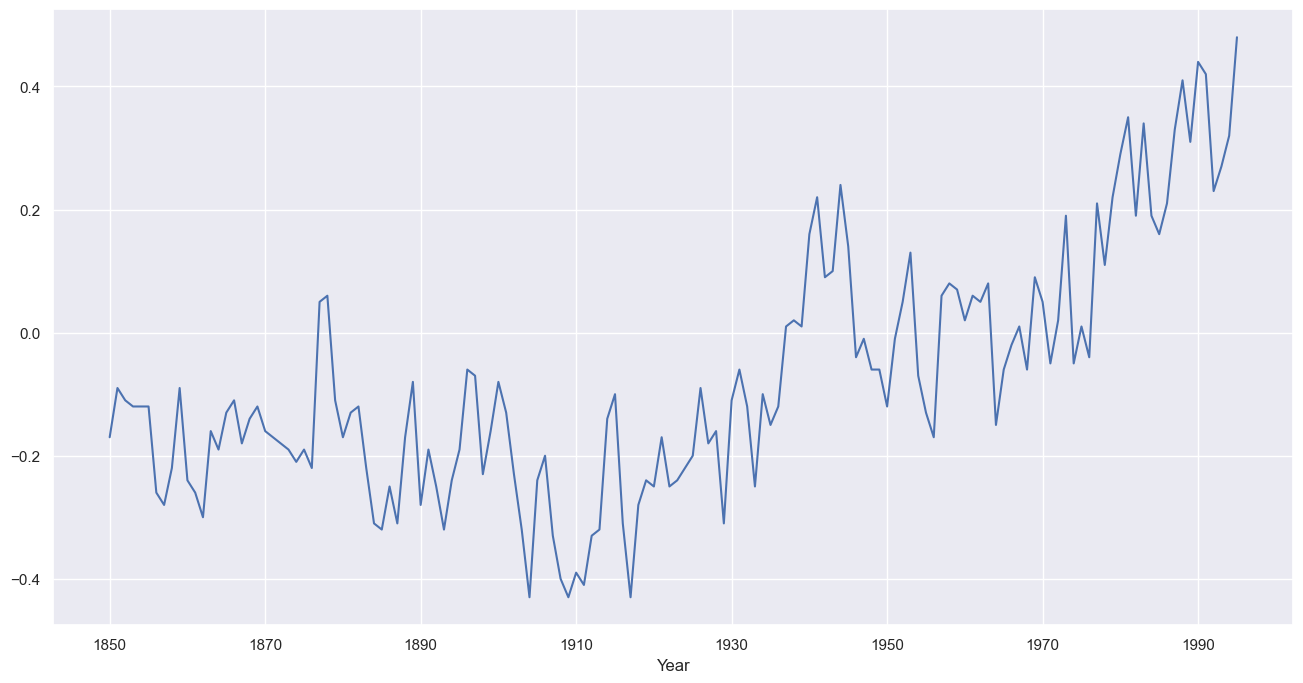

In [ ]:
train_df['color'] = 'b'
train_df.set_index(time_col)[target_col].plot(figsize=figsize, color=train_df['color']);

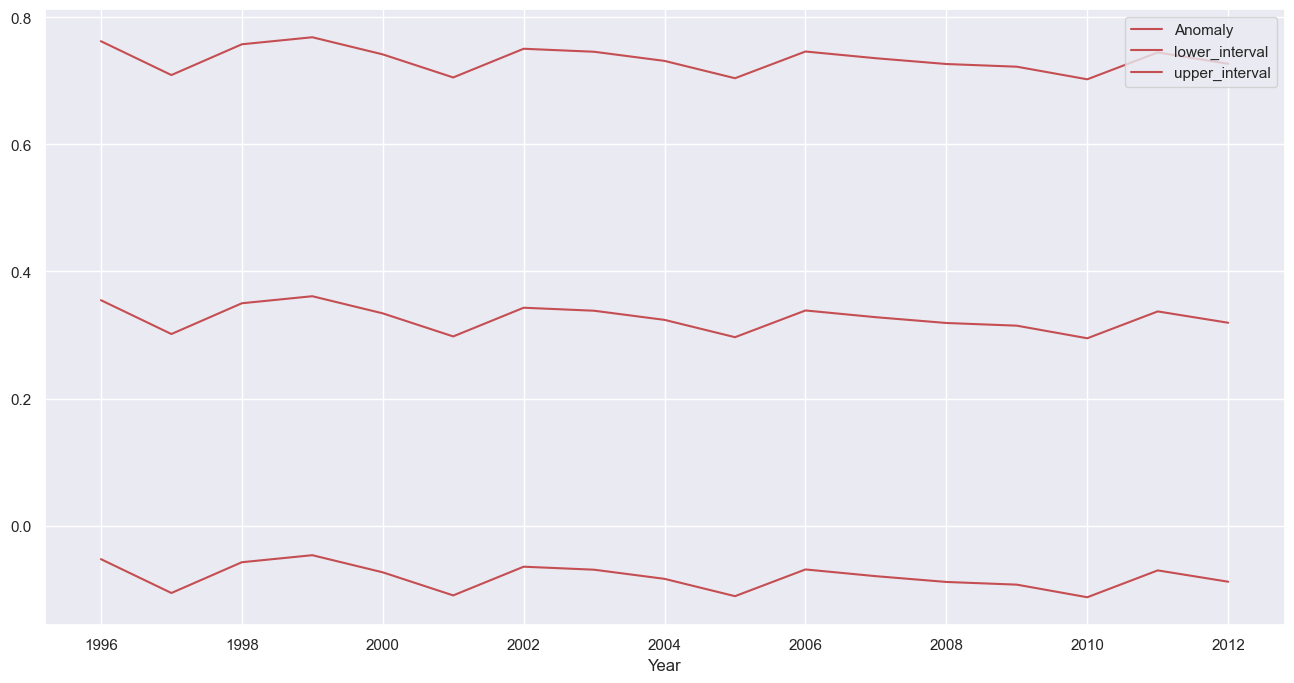

In [ ]:
forecast_df['color'] = 'r'
forecast_df.set_index(time_col).plot(figsize=figsize, color=forecast_df['color']);

Combine train and forecast sets

In [ ]:
df = pd.concat([train_df, forecast_df]).reset_index(drop=True)

In [ ]:
df.shape

(163, 14)

In [ ]:
df.head()

,Year,WMGHG,Ozone,Solar,Land_Use,SnowAlb_BC,Orbital,TropAerDir,TropAerInd,StratAer,Anomaly,color,lower_interval,upper_interval
0,1850,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.17,b,NaN,NaN
1,1851,0.005954,0.000745,0.001166,-0.000940,0.000649,0.000653,0.000649,-0.000005,0.029088,-0.09,b,NaN,NaN
2,1852,0.010502,0.000909,-0.010756,-0.002531,0.000649,0.000671,0.000649,-0.000005,0.056712,-0.11,b,NaN,NaN
3,1853,0.014587,0.001020,-0.027220,-0.004123,0.000649,0.000688,0.000649,-0.000005,0.077260,-0.12,b,NaN,NaN
4,1854,0.020521,0.001188,-0.045539,-0.005717,0.000649,0.000689,0.000649,-0.000005,0.085759,-0.12,b,NaN,NaN


In [ ]:
df.tail()

,Year,WMGHG,Ozone,Solar,Land_Use,SnowAlb_BC,Orbital,TropAerDir,TropAerInd,StratAer,Anomaly,color,lower_interval,upper_interval
158,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.318894,r,-0.088764,0.726552
159,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.314655,r,-0.093003,0.722313
160,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.294820,r,-0.112838,0.702478
161,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337095,r,-0.070563,0.744753
162,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.319245,r,-0.088413,0.726903


In [ ]:
df['Anomaly']

0     -0.170000
1     -0.090000
2     -0.110000
3     -0.120000
4     -0.120000
         ...   
158    0.318894
159    0.314655
160    0.294820
161    0.337095
162    0.319245
Name: Anomaly, Length: 163, dtype: float64

In [ ]:
dataset

,Year,WMGHG,Ozone,Solar,Land_Use,SnowAlb_BC,Orbital,TropAerDir,TropAerInd,StratAer,Anomaly
0,1850,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.17
1,1851,0.005954,0.000745,0.001166,-0.000940,0.000649,0.000653,0.000649,-0.000005,0.029088,-0.09
2,1852,0.010502,0.000909,-0.010756,-0.002531,0.000649,0.000671,0.000649,-0.000005,0.056712,-0.11
3,1853,0.014587,0.001020,-0.027220,-0.004123,0.000649,0.000688,0.000649,-0.000005,0.077260,-0.12
4,1854,0.020521,0.001188,-0.045539,-0.005717,0.000649,0.000689,0.000649,-0.000005,0.085759,-0.12
...,...,...,...,...,...,...,...,...,...,...,...
158,2008,3.366880,0.451834,-0.009377,-0.205278,0.053937,0.002234,-0.189395,-0.697385,0.059742,0.55
159,2009,3.409630,0.451834,-0.006203,-0.205278,0.053937,0.002241,-0.189395,-0.697385,0.040626,0.66
160,2010,3.450820,0.451834,0.020822,-0.205278,0.053937,0.002254,-0.189395,-0.697385,0.081508,0.73
161,2011,3.492780,0.451834,0.058369,-0.205278,0.053937,0.002261,-0.189395,-0.697385,0.088224,0.62


Plot combined train and forecast sets with the vertical black line as the cut-off

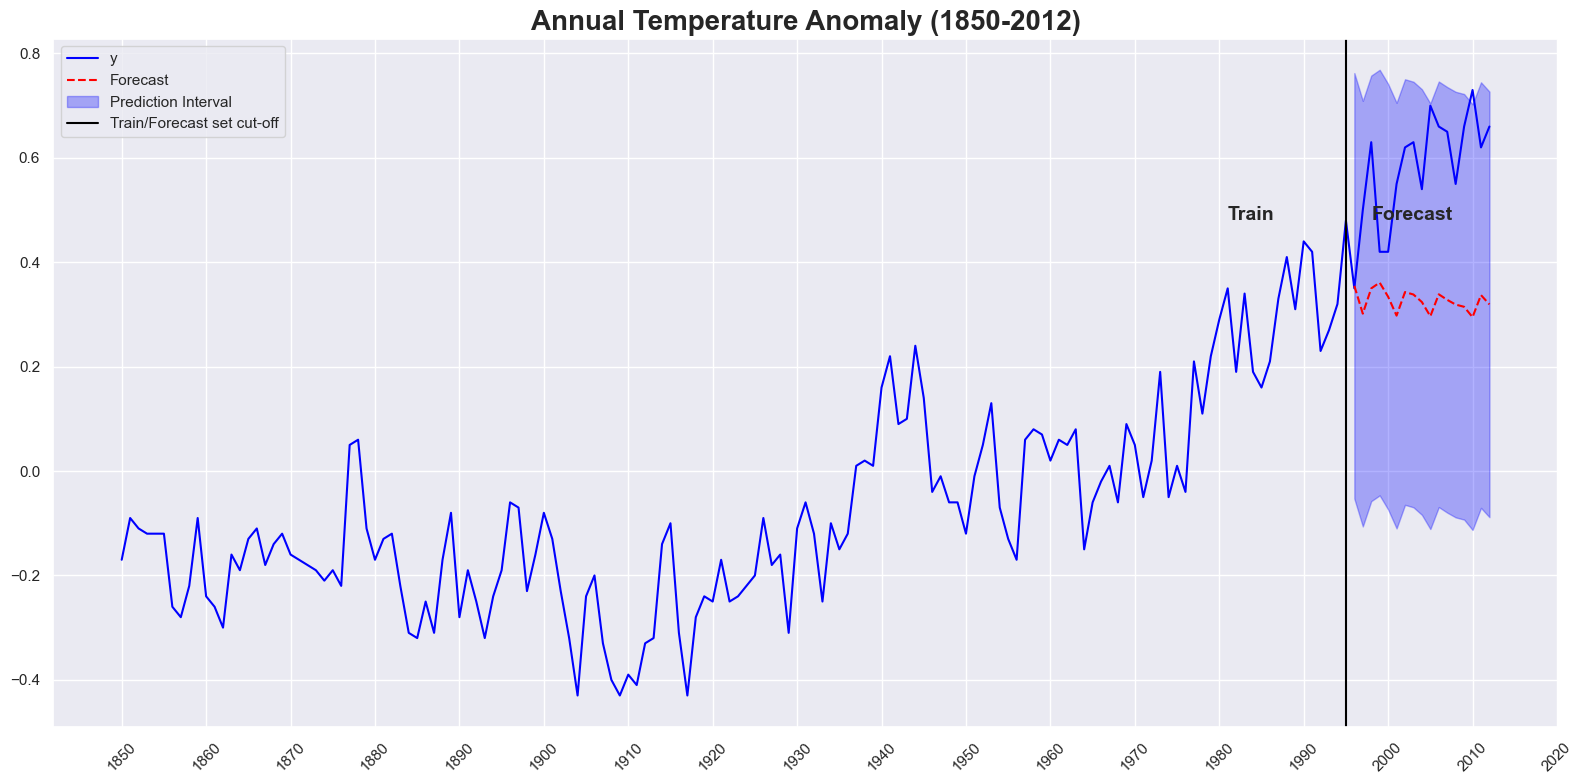

In [ ]:
import matplotlib.dates as mdates

# Ensure time_col is datetime
df[time_col] = pd.to_datetime(df[time_col])
forecast_df[time_col] = pd.to_datetime(forecast_df[time_col])

plt.figure(figsize=figsize)
dataset['Year'] = pd.to_datetime(dataset['Year'], format='%Y')

plt.plot(dataset[time_col], dataset[target_col], color='blue', label='y')

plt.plot(forecast_df[time_col], forecast_df[target_col], color='red', linestyle='dashed', label='Forecast')

plt.fill_between(forecast_df[time_col], forecast_df['lower_interval'], forecast_df['upper_interval'], 
                 color='blue', alpha=0.3, label='Prediction Interval')

plt.axvline(x=df[time_col].iloc[len(train_df)-1], color='black', label='Train/Forecast set cut-off')

plt.text(df[time_col].iloc[len(train_df)-15], df[target_col].max(), 'Train', fontweight='bold', fontsize=14)
plt.text(df[time_col].iloc[len(train_df)+2], df[target_col].max(), 'Forecast', fontweight='bold', fontsize=14)

# Format x-axis to show years clearly
plt.gca().xaxis.set_major_locator(mdates.YearLocator(10))  # every 10 years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title('Hourly Recorded Temperature', fontweight='bold', fontsize=20)
plt.legend()
plt.tight_layout()
plt.show()


